INFO       No numerical integration method specified for group 'neurongroup_1', using method 'euler' (took 0.01s, trying other methods took 0.05s). [brian2.stateupdaters.base.method_choice]
INFO       No numerical integration method specified for group 'neurongroup', using method 'euler' (took 0.00s, trying other methods took 0.05s). [brian2.stateupdaters.base.method_choice]
WARNING    'dt' is an internal variable of group 'poissongroup_1', but also exists in the run namespace with the value 20. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'dt' is an internal variable of group 'poissongroup_2', but also exists in the run namespace with the value 20. * usecond. The internal variable will be used. [brian2.groups.group.Group.resolve.resolution_conflict]
WARNING    'dt' is an internal variable of group 'poissongroup_3', but also exists in the run namespace with the value 20. * usecond. The internal variable will be used. 

Starting simulation at t=0. s for a duration of 4.5 s


WARNING    /opt/anaconda3/lib/python3.13/site-packages/brian2/core/variables.py:1358: ComplexWarning: Casting complex values to real discards the imaginary part
  variable.get_value()[indices] = value
 [py.warnings]


204.74 ms (4%) simulated in 10s, estimated 3m 30s remaining.
0.41126 s (9%) simulated in 20s, estimated 3m 19s remaining.
0.61166 s (13%) simulated in 30s, estimated 3m 11s remaining.
0.81532 s (18%) simulated in 40s, estimated 3m 1s remaining.
1.00294 s (22%) simulated in 50s, estimated 2m 54s remaining.
1.19262 s (26%) simulated in 1m 0s, estimated 2m 46s remaining.
1.39068 s (30%) simulated in 1m 10s, estimated 2m 37s remaining.
1.58782 s (35%) simulated in 1m 20s, estimated 2m 27s remaining.
1.7904 s (39%) simulated in 1m 30s, estimated 2m 16s remaining.
1.9942 s (44%) simulated in 1m 40s, estimated 2m 6s remaining.
2.19828 s (48%) simulated in 1m 50s, estimated 1m 55s remaining.
2.3995 s (53%) simulated in 2m 0s, estimated 1m 45s remaining.
2.60642 s (57%) simulated in 2m 10s, estimated 1m 34s remaining.
2.81288 s (62%) simulated in 2m 20s, estimated 1m 24s remaining.
3.0118 s (66%) simulated in 2m 30s, estimated 1m 14s remaining.
3.21452 s (71%) simulated in 2m 40s, estimated 1m 

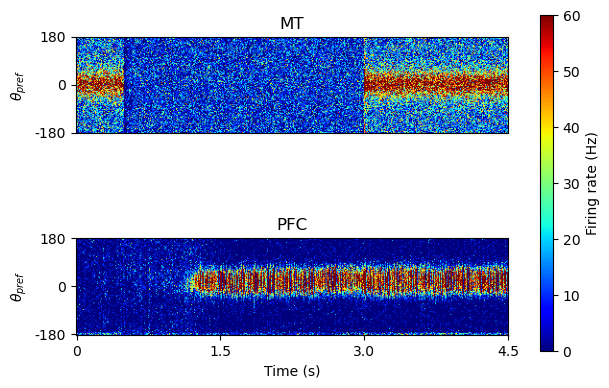

In [1]:
# %%
"""
Double ring model

References:
Ardid, Wang, Compte 2007 Journal of Neuroscience
doi: 10.1523/JNEUROSCI.1145-07.2007

Edited for Brian2 and Python3 by Deying Song, 09/2024
Mirrored by John Meng, 09/2024 from
https://github.com/deyingsong/ardid2007_brian2/blob/main/ardid2007_brian2.py

"""
from __future__ import division
from collections import OrderedDict
from brian2 import *
import scipy.stats

# Notice scipy.fftpack.rfft behaves differently from numpy.fft.rfft
from numpy.fft import rfft, irfft

prefs.codegen.cpp.extra_compile_args_gcc = ['-ffast-math', '-march=native']

#=========================================================================================
# Helper function
#=========================================================================================

def angle_diff(theta1, theta2, mode='rad'):
    # Compute the angle difference between theta1 and theta2 on a circle
    angle_circle = 2*np.pi if mode == 'rad' else 360.
    diff = abs(theta1-theta2)
    return np.minimum(diff, angle_circle-diff)


#=========================================================================================
# Equations
#=========================================================================================

equations = dict(
    E = '''
    dV/dt         = (-(V - V_L) + Isyn/gE) / tau_m_E : volt (unless refractory)
    dsAMPA/dt     = -sAMPA/tauAMPA : 1
    dx/dt         = -x/tau_x : 1
    dsNMDA/dt     = -sNMDA/tauNMDA + alpha*x*(1 - sNMDA) : 1
    Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA + Istim : amp
    I_AMPA_ext    = -G_AMPA_ext*(V - V_E) : amp
    I_AMPA        = -G_AMPA*(V - V_E) : amp
    I_NMDA        = -G_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = -G_GABA*(V - V_I) : amp
    dG_AMPA_ext/dt= -G_AMPA_ext/tauAMPA : siemens
    G_AMPA : siemens
    G_NMDA : siemens
    G_GABA : siemens
    Istim  : amp
    ''',

    I = '''
    dV/dt         = (-(V - V_L) + Isyn/gI) / tau_m_I : volt (unless refractory)
    dsGABA/dt     = -sGABA/tauGABA : 1
    Isyn          = I_AMPA_ext + I_AMPA + I_NMDA + I_GABA : amp
    I_AMPA_ext    = -G_AMPA_ext*(V - V_E) : amp
    I_AMPA        = -G_AMPA*(V - V_E) : amp
    I_NMDA        = -G_NMDA*(V - V_E)/(1 + exp(-a*V)/b) : amp
    I_GABA        = -G_GABA*(V - V_I) : amp
    dG_AMPA_ext/dt= -G_AMPA_ext/tauAMPA : siemens
    G_AMPA: siemens
    G_NMDA: siemens
    G_GABA: siemens
    Istim: amp
    '''
    )


#=========================================================================================
# Model Parameters
#=========================================================================================

modelparams = dict()

modelparams['neuron'] = dict(
    # Number of neurons
    N_E = 1024,
    N_I = 256,

    # Common LIF
    V_L    = -70*mV,
    Vth    = -50*mV,
    Vreset = -60*mV,

    # Excitatory LIF
    gE        = 25*nS,
    tau_m_E   = 20*ms,
    tau_ref_E = 2*ms,

    # Inhibitory LIF
    gI        = 20*nS,
    tau_m_I   = 10*ms,
    tau_ref_I = 1*ms,

    # Reversal potentials
    V_E = 0*mV,
    V_I = -70*mV,

    # NMDA nonlinearity
    a = 0.062*mV**-1,
    b = 3.57,

    # Synaptic time constants
    tauAMPA = 2*ms,
    tau_x   = 2*ms,
    tauNMDA = 100*ms,
    alpha   = 0.5*kHz,
    tauGABA = 10*ms,

    # Background noise
    nu_ext = 1.8*kHz
    )

modelparams['mt'] = dict(
    # recurrent connectivity footprint
    sigma_EE = 14.4,
    JEE_plus = 1.62,

    # Unscaled recurrent synaptic conductances (onto excitatory)
    gAMPA_E = 0.005*1024*nS,
    gNMDA_E = 0.093*1024*nS,
    gGABA_E = 1.47*256*nS,

    # Unscaled recurrent synaptic conductances (onto inhibitory)
    gAMPA_I = 0.005*1024*nS,
    gNMDA_I = 0.195*1024*nS,
    gGABA_I = 0.391*256*nS,

    # External synaptic conductances
    gAMPA_ext_E = 15.0*nS,
    gAMPA_ext_I = 4.5*nS,
    )

modelparams['pfc'] = dict(
    # recurrent connectivity footprint
    sigma_EE = 14.4,
    JEE_plus = 1.62,

    # Unscaled recurrent synaptic conductances (onto excitatory)
    gAMPA_E = 0.391*1024*nS,
    gNMDA_E = 0.732*1024*nS,
    gGABA_E = 3.74*256*nS,

    # Unscaled recurrent synaptic conductances (onto inhibitory)
    gAMPA_I = 0.293*1024*nS,
    gNMDA_I = 0.566*1024*nS,
    gGABA_I = 2.87*256*nS,

    # External synaptic conductances
    gAMPA_ext_E = 3.1*nS,
    gAMPA_ext_I = 2.38*nS
    )

modelparams['conn'] = dict(
    # Connectivity footprint
    sigma_mt2pfc = 36.,
    sigma_pfc2mt = 72.,

    # Unscaled long range synaptic conductances (onto excitatory)
    gAMPA_E_mt2pfc = 0.005*1024*nS,
    gAMPA_E_pfc2mt = 0.146*1024*nS,

    # Unscaled long range synaptic conductances (onto inhibitory)
    gAMPA_I_mt2pfc = 0*nS,
    gAMPA_I_pfc2mt = 0.039*1024*nS
    )

#=========================================================================================
# Stimulus Parameters
#=========================================================================================

stimparams = dict(
    Tcue  = 500 * ms,
    Tdelay = 2500 * ms,
    Ttest = 1500 * ms,
    I0_E = 1. * nA,
    I1_E = 0.9 * nA,
    I0_I = 0.2 * nA,
    I1_I = 0.18 * nA,
    mu   = 2.53,
    theta_stim = 180,
    theta_attention = 180,
    attention_flag = True,
    Igate = 0.025 * nA
    )

#=========================================================================================
# Model
#=========================================================================================

class Model(object):
    def __init__(self, modelparams, stimparams, dt=0.02*ms):
        #---------------------------------------------------------------------------------
        # Initialize
        #---------------------------------------------------------------------------------

        dt_main = dt
        dt_NMDA = dt*10
        dt_stim = 10*ms

        #---------------------------------------------------------------------------------
        # Complete the model specification
        #---------------------------------------------------------------------------------

        # Model parameters
        p = modelparams.copy()
        p_neuron = p['neuron']

        areas = ['mt','pfc']        # areas
        conns = ['pfc2mt','mt2pfc'] # connections

        # Rescale conductances by number of neurons
        for area in areas:
            for conductance in ['gAMPA_E', 'gAMPA_I', 'gNMDA_E', 'gNMDA_I']:
                p[area][conductance] /= p_neuron['N_E']
            for conductance in ['gGABA_E', 'gGABA_I']:
                p[area][conductance] /= p_neuron['N_I']

        for conn in conns:
            p['conn']['gAMPA_E_'+conn] /= p_neuron['N_E']
            p['conn']['gAMPA_I_'+conn] /= p_neuron['N_E']

        #---------------------------------------------------------------------------------
        # Neuron populations
        #---------------------------------------------------------------------------------

        net = OrderedDict() # Network objects
        exc = OrderedDict()
        inh = OrderedDict()

        # E/I populations
        for pop in ['E', 'I']:
            net[pop] = NeuronGroup(len(areas)*p_neuron['N_'+pop],
                                 equations[pop], 
                                 threshold='V > Vth',
                                 reset='V = Vreset',
                                 refractory=p_neuron['tau_ref_'+pop],
                                 namespace=p_neuron,
                                 order=1) # freeze=True

        # Excitatory subpopulations
        exc['mt'] = net['E'][:p_neuron['N_E']]
        exc['pfc'] = net['E'][p_neuron['N_E']:]
        inh['mt'] = net['I'][:p_neuron['N_I']]
        inh['pfc'] = net['I'][p_neuron['N_I']:]

        #---------------------------------------------------------------------------------
        # Background AMPA input (post-synaptic)
        #---------------------------------------------------------------------------------

        for area in areas:
            for pop, target in zip(['E','I'], [exc,inh]):
                net['pg'+area+pop] = PoissonGroup(p_neuron['N_'+pop], p_neuron['nu_ext'])
                net['ic'+area+pop] = Synapses(net['pg'+area+pop], target[area], 'w: siemens',
                                              on_pre="G_AMPA_ext += w")
                net['ic'+area+pop].connect(condition='i == j')
                net['ic'+area+pop].w = p[area]['gAMPA_ext_'+pop]
                # IdentityConnection(net['pg'+area+pop], target[area], 'G_AMPA_ext',
                #                                   weight=p[area]['gAMPA_ext_'+pop])

        #---------------------------------------------------------------------------------
        # Recurrent connections
        #---------------------------------------------------------------------------------

        # Presynaptic variables
        net['icAMPA'] = Synapses(net['E'], net['E'], on_pre='sAMPA += 1')
        net['icAMPA'].connect(condition='i==j')
        # IdentityConnection(net['E'], net['E'], 'sAMPA')
        net['icNMDA'] = Synapses(net['E'], net['E'], on_pre='x += 1')
        net['icNMDA'].connect(condition='i==j')
        # IdentityConnection(net['E'], net['E'], 'x')
        net['icGABA'] = Synapses(net['I'], net['I'], on_pre='sGABA += 1')
        net['icGABA'].connect(condition='i == j')
        # IdentityConnection(net['I'], net['I'], 'sGABA')

        def get_fw(N, sigma, J_plus=None):
            dtheta = 2*np.pi*np.minimum(np.arange(N),N-np.arange(N))/N
            if J_plus is not None:
                sigma = deg2rad(sigma)
                tmp = (2*scipy.stats.norm.cdf(np.pi/sigma)-1)/np.sqrt(2*np.pi)*sigma
                J_minus = (1-J_plus*tmp)/(1-tmp)
                w = J_minus+((J_plus-J_minus)*np.exp(-dtheta**2/2./sigma**2))
            else:
                w = np.exp(-dtheta**2/2./sigma**2)/sigma/np.sqrt(2*np.pi)
            return rfft(w)

        # Recurrent NMDA connections
        N_E      = p_neuron['N_E']
        self.fw = dict()
        for area in areas:
            self.fw[area] = get_fw(N_E, p[area]['sigma_EE'], p[area]['JEE_plus'])

        p_conn = p['conn']
        for conn in ['pfc2mt','mt2pfc']:
            self.fw[conn] = get_fw(N_E, p_conn['sigma_'+conn])

        # PFC, MT only have within area NMDA connections
        @network_operation(when='start', dt=dt_NMDA)
        def recurrent_NMDA():
            for area in areas:
                fsNMDA = rfft(self.exc[area].sNMDA)
                self.exc[area].G_NMDA = irfft(self.fw[area] * fsNMDA, N_E) * p[area]['gNMDA_E']
                self.inh[area].G_NMDA = fsNMDA[0]  * p[area]['gNMDA_I']

        # Recurrent GABA connections
        @network_operation(when='start', dt=dt_main)
        def recurrent_GABA():
            for area in areas:
                S = sum(self.inh[area].sGABA)
                self.exc[area].G_GABA = S * p[area]['gGABA_E']
                self.inh[area].G_GABA = S * p[area]['gGABA_I']

        # AMPA
        @network_operation(when='start', dt=dt_main)
        def recurrent_AMPA():
            fsAMPA = dict()
            for area in areas:
                fsAMPA[area] = rfft(self.exc[area].sAMPA)
                self.exc[area].G_AMPA = irfft(self.fw[area] * fsAMPA[area], N_E) * p[area]['gAMPA_E']
                self.inh[area].G_AMPA = fsAMPA[area][0]  * p[area]['gAMPA_I']

            for conn in conns:
                area_from, area_to = conn.split('2')
                tmp = irfft(self.fw[conn] * fsAMPA[area_from], N_E)
                self.exc[area_to].G_AMPA += p_conn['gAMPA_E_'+conn] * tmp
                # slicing [3::4] start from index 3 and take one every 4 number
                self.inh[area_to].G_AMPA += p_conn['gAMPA_I_'+conn] * tmp[3::4]
        #---------------------------------------------------------------------------------
        # Stimulus
        #---------------------------------------------------------------------------------

        # clocks['stim'] = Clock(10*ms)
        @network_operation(when='start', dt=dt_stim)
        def stimulus():
            t = defaultclock.t
            if t < self.stimparams['Tcue']:
                if self.stimparams['attention_flag']:
                    self.exc['mt'].Istim = self.Istim['E'+'theta_attention']
                    self.inh['mt'].Istim = self.Istim['I'+'theta_attention']
                    self.exc['pfc'].Istim = self.stimparams['Igate']
                    self.inh['pfc'].Istim = self.stimparams['Igate']
                else:
                    self.exc['mt'].Istim = 0
                    self.inh['mt'].Istim = 0
                    self.exc['pfc'].Istim = 0
                    self.inh['pfc'].Istim = 0
            elif self.stimparams['Tcue'] <= t < self.stimparams['Tcue'] + self.stimparams['Tdelay']:
                if self.stimparams['attention_flag']:
                    self.exc['mt'].Istim = 0
                    self.inh['mt'].Istim = 0
                    self.exc['pfc'].Istim = self.stimparams['Igate']
                    self.inh['pfc'].Istim = self.stimparams['Igate']
                else:
                    self.exc['mt'].Istim = 0
                    self.inh['mt'].Istim = 0
                    self.exc['pfc'].Istim = 0
                    self.inh['pfc'].Istim = 0
            else:
                if self.stimparams['attention_flag']:
                    self.exc['mt'].Istim = self.Istim['E'+'theta_stim']
                    self.inh['mt'].Istim = self.Istim['I'+'theta_stim']
                    self.exc['pfc'].Istim = self.stimparams['Igate']
                    self.inh['pfc'].Istim = self.stimparams['Igate']
                else:
                    self.exc['mt'].Istim = self.Istim['E'+'theta_stim']
                    self.inh['mt'].Istim = self.Istim['I'+'theta_stim']
                    self.exc['pfc'].Istim = 0
                    self.inh['pfc'].Istim = 0

        #---------------------------------------------------------------------------------
        # Record spikes
        #---------------------------------------------------------------------------------

        mons = OrderedDict()
        var_list = ['G_AMPA', 'G_NMDA', 'G_GABA', 'V', 'G_AMPA_ext',
                    'I_AMPA', 'I_NMDA', 'I_GABA', 'Isyn']
        for pop in ['E', 'I']:
            mons['spike'+pop] = SpikeMonitor(net[pop], record=True)
            mons['pop'+pop]   = PopulationRateMonitor(net[pop])
            for var in var_list:
                mons[var+pop] = StateMonitor(net[pop], var, record=True, dt=1.0*ms)

        for pop, target in zip(['E','I'], [exc,inh]):
            for area in areas:
                mons['spike'+area+pop] = SpikeMonitor(target[area], record=True)
                mons['pop'+area+pop]   = PopulationRateMonitor(target[area])

        pop = 'E'
        for var in ['x','sNMDA','Istim']:
            mons[var+pop] = StateMonitor(net[pop], var, record=True, dt=1.0*ms)
        #---------------------------------------------------------------------------------
        # Setup
        #---------------------------------------------------------------------------------

        self.p          = p
        self.stimparams = stimparams
        self.net        = net
        self.exc        = exc
        self.inh        = inh
        self.mons       = mons

        # Add network objects and monitors to NetworkOperation's contained_objects
        self.contained_objects = list(self.net.values()) + list(self.mons.values())
        self.contained_objects += [recurrent_GABA,recurrent_NMDA,recurrent_AMPA]
        self.contained_objects += [stimulus]

    def reinit(self):
        # Randomly initialize membrane potentials
        for pop in ['E', 'I']:
            self.net[pop].V = np.random.uniform(self.p['neuron']['Vreset'],
                                                self.p['neuron']['Vth'],
                                                size=len(self.net[pop].V)) * volt

        # Set synaptic variables to zero
        for var in ['sAMPA', 'x', 'sNMDA']:
            setattr(self.net['E'], var, 0)
        for var in ['sGABA']:
            setattr(self.net['I'], var, 0)

        # Set stimulus
        self.Istim = dict()
        for pop in ['E', 'I']:
            N = self.p['neuron']['N_'+pop]
            for theta1 in ['theta_stim', 'theta_attention']:
                dtheta = deg2rad(angle_diff(stimparams[theta1], np.arange(N)/N*360., 'deg'))
                self.Istim[pop+theta1]  = (stimparams['I0_'+pop] +
                stimparams['I1_'+pop] * np.exp(stimparams['mu']*(np.cos(dtheta)-1)))


class Simulation(object):
    def __init__(self,modelparams, stimparams, dt=0.02*ms):
        defaultclock.dt = dt
        self.model = Model(modelparams, stimparams, dt)
        self.network = Network(self.model.contained_objects)

    def run(self, T, randseed=1234):
        seed(randseed)
        self.model.reinit()
        self.network.run(T, report='text')

    def savespikes(self, filename_exc, filename_inh):
        print("Saving excitatory spike times to " + filename_exc)
        np.savetxt(filename_exc, list(zip(list(self.model.mons['spikeE'].i),
                                     list(self.model.mons['spikeE'].t))), fmt='%-9d %25.18e',
                   header='{:<8} {:<25}'.format('Neuron', 'Time (s)'))

        print("Saving inhibitory spike times to " + filename_inh)
        np.savetxt(filename_inh, list(zip(list(self.model.mons['spikeI'].i),
                                     list(self.model.mons['spikeI'].t))), fmt='%-9d %25.18e',
                   header='{:<8} {:<25}'.format('Neuron', 'Time (s)'))
        
    def loadspikes(self, *args):
        return [np.loadtxt(filename) for filename in args]


#/////////////////////////////////////////////////////////////////////////////////////////

if __name__ == '__main__':
    dt = 0.02*ms
    T  = stimparams['Tcue']+stimparams['Tdelay']+stimparams['Ttest']

    # Setup the network
    sim = Simulation(modelparams, stimparams, dt)
    sim.run(T)
    sim.savespikes('./spikesE.txt', './spikesI.txt')

    spikes, = sim.loadspikes('./spikesE.txt')

    import matplotlib.pyplot as plt
    import numpy as np

    spike_time = spikes[:,1]
    spike_ind = spikes[:,0]
    edge_time = np.linspace(0.0, 4.5, num=451)
    edge_ind = np.linspace(0, 2000, num=201)

    H, _, _ = np.histogram2d(spike_time, spike_ind, bins=(edge_time, edge_ind))  

    H = H.T*100.0/10.0

    fig, axs = plt.subplots(2, 1)
    ax1=axs[0]
    ax2=axs[1]

    ax1=plt.subplot(211)
    ax1.imshow(H[:100,:], cmap='jet', vmin=0, vmax=60, origin='lower')
    ax1.set_yticks([0,50,100])
    ax1.set_yticklabels(['-180','0','180'])
    ax1.set_ylabel('$\\theta_{pref}$')
    ax1.set_xticks([])
    ax1.set_title('MT')

    ax2=plt.subplot(212)
    im=ax2.imshow(H[100:,:], cmap='jet', vmin=0, vmax=60, origin='lower')
    ax2.set_yticks([0,50,100])
    ax2.set_yticklabels(['-180','0','180'])
    ax2.set_ylabel('$\\theta_{pref}$')
    ax2.set_xticks([0,150,300,450])
    ax2.set_xticklabels(['0','1.5','3.0','4.5'])
    ax2.set_xlabel('Time (s)')
    ax2.set_title('PFC')

    fig.subplots_adjust(right=0.8)
    cbar_ax = fig.add_axes([0.85, 0.15, 0.02, 0.7])
    fig.colorbar(im, cax=cbar_ax, label='Firing rate (Hz)')

    print("Saving raster plot to ardid2007.pdf")
    plt.savefig('./ardid2007.pdf')



# %%


